In [1]:
import os
import time

import netCDF4 as nc4

os.environ["TZ"] = "UTC"
time.tzset()

import datetime

from icecream import ic

import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import matplotlib.ticker as mticker

import cartopy.crs as ccrs
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

import numpy as np

import matplotlib.cm as mplcm
import matplotlib.colors as colors

from data_tools import dict_extracted_data, dict_extracted_data_2018, dict_extracted_data_2021, load_sic
from data_tools import generate_lists_data, instrument_label, ColormapMapper

import cartopy.crs as ccrs
import pyproj

from scipy.interpolate import splprep, splev

from mpl_toolkits.axes_grid1 import host_subplot
import mpl_toolkits.axisartist as AA

import xarray as xa


/home/jeanr/Desktop/Git/periodic_oscillation_wave_damping_2021_svalbard_waves_in_ice_arven_etter_nansen/cleaned_notebooks/convergence_divergence_from_satellite_and_buoy_trajectories/data_tools.py:70: UserWarning: Warning: converting a masked element to nan.
  crrt_dict_wave["swh"] = float(array_swh[crrt_index])
/home/jeanr/Desktop/Git/periodic_oscillation_wave_damping_2021_svalbard_waves_in_ice_arven_etter_nansen/cleaned_notebooks/convergence_divergence_from_satellite_and_buoy_trajectories/data_tools.py:73: UserWarning: Warning: converting a masked element to nan.
  crrt_dict_wave["tz0"] = float(array_tz0[crrt_index])


In [2]:
nps = ccrs.NorthPolarStereo()
plc = ccrs.PlateCarree()

ic.configureOutput(prefix="", outputFunction=print)

print("***** configure matplotlib")
plt.rcParams.update({'font.size': 20})
list_colors = list(mcolors.TABLEAU_COLORS)
list_colors.append("k")

NUM_COLORS = 20

cm = plt.get_cmap('gist_rainbow')
cNorm = colors.Normalize(vmin=0, vmax=NUM_COLORS - 1)
scalarMap = mplcm.ScalarMappable(norm=cNorm, cmap=cm)

event_1_start = datetime.datetime(2021, 3, 1, 0, 0, 0)
event_1__stop = datetime.datetime(2021, 3, 3, 23, 59, 59)

# all the instruments around
list_instruments_neighborhood = [
    '200913',
    '13319',
    '200905',
    '19612',
    '19631',
    '19633',
    '19636',
    '19643',
    '19648',
]

list_most_relevant_instruments = [
    "19648",
    "200905",
    "13319",
    # ignore the following - bad data, too close, etc - only makes for trouble
    # "19636",
    # "19612",
    # "19631",
    # "200913",
]

# do we want to keep only the most relevant instruments displaying the modulation?
# event_1_list_instruments_neighborhood = list_instruments_neighborhood
event_1_list_instruments_neighborhood = list_most_relevant_instruments

dict_lists_data = generate_lists_data(
    dict_extracted_data,
    event_1_list_instruments_neighborhood,
    event_1_start,
    event_1__stop
)

dict_lists_data_all = generate_lists_data(
    dict_extracted_data,
    list(dict_extracted_data),
    event_1_start,
    event_1__stop
)

***** configure matplotlib


In [3]:
t0 = datetime.datetime(2021, 3, 1)

delta_t = 0.02
ui = np.arange(0, 4.02, 0.02)

drifters = {}

for d in dict_extracted_data:
    dd = dict_extracted_data[d]['time_pos']

    times = np.array([t for t in dd])
    days = np.array([(t - t0).total_seconds()/60/60/24 for t in dd])
    lats = np.array([dd[t][0] for t in dd])
    lons = np.array([dd[t][1] for t in dd])
    
    gpi = np.where((days > -1) * (days < 5))[0]
    if gpi.size > 0:
        days, lats, lons, times = [i[gpi] for i in [days, lats, lons, times]]
        j = np.argsort(days)
        days, lats, lons, times = [i[j] for i in [days, lats, lons, times]]
        x, y, _ = nps.transform_points(plc, lons, lats).T
        tck, u = splprep([x, y], u=days, s=0)
        xi, yi = splev(ui, tck)
        tck, u = splprep([lats, lons], u=days, s=0)
        latsi, lonsi = splev(ui, tck)
        drifters[d] = dict(d=days, x=x, y=y, xi=xi, yi=yi, lats=lats, lons=lons, times=times, latsi=latsi, lonsi=lonsi)
        

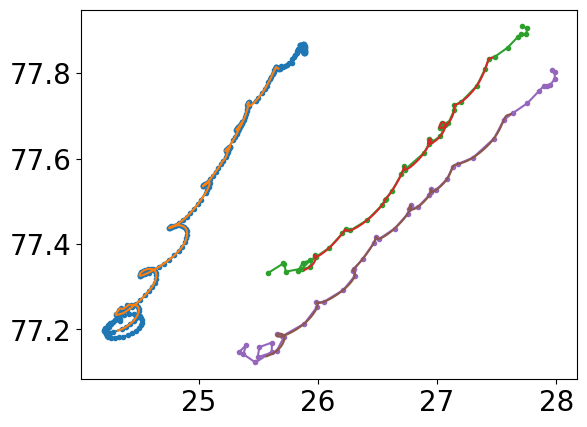

In [4]:
good_drifters = list_most_relevant_instruments

for gd in good_drifters:
    d = drifters[str(gd)]
    plt.plot(d['lons'], d['lats'], '.-')
    plt.plot(d['lonsi'], d['latsi'])

In [5]:
d['times']

array([datetime.datetime(2021, 2, 28, 0, 26),
       datetime.datetime(2021, 2, 28, 3, 5, 36),
       datetime.datetime(2021, 2, 28, 6, 11, 1),
       datetime.datetime(2021, 2, 28, 9, 15, 56),
       datetime.datetime(2021, 2, 28, 11, 55, 34),
       datetime.datetime(2021, 2, 28, 14, 35, 41),
       datetime.datetime(2021, 2, 28, 17, 15, 49),
       datetime.datetime(2021, 2, 28, 20, 21, 17),
       datetime.datetime(2021, 2, 28, 23, 26, 11),
       datetime.datetime(2021, 3, 1, 4, 19, 36),
       datetime.datetime(2021, 3, 1, 7, 24, 10),
       datetime.datetime(2021, 3, 1, 10, 28, 57),
       datetime.datetime(2021, 3, 1, 13, 33, 47),
       datetime.datetime(2021, 3, 1, 16, 39, 19),
       datetime.datetime(2021, 3, 1, 19, 43, 25),
       datetime.datetime(2021, 3, 1, 22, 48, 6),
       datetime.datetime(2021, 3, 2, 1, 27, 26),
       datetime.datetime(2021, 3, 2, 4, 31, 52),
       datetime.datetime(2021, 3, 2, 7, 11, 9),
       datetime.datetime(2021, 3, 2, 10, 15, 31),
       d

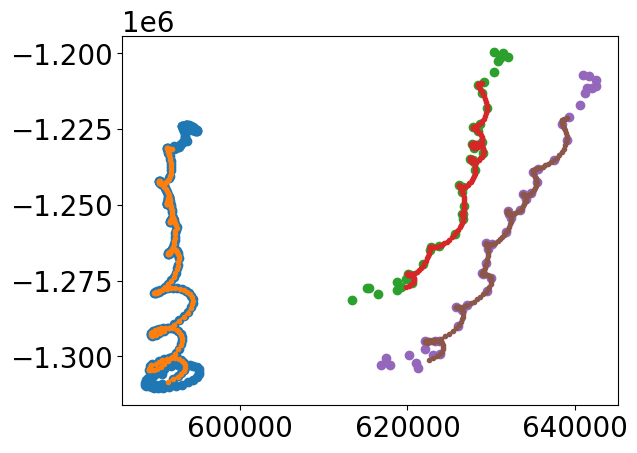

In [6]:
good_drifters = list_most_relevant_instruments

for gd in good_drifters:
    d = drifters[str(gd)]
    plt.plot(d['x'], d['y'], 'o')
    plt.plot(d['xi'], d['yi'], '.-')
    
plt.savefig("buoys_of_interest_trajectories.pdf")
plt.savefig("buoys_of_interest_trajectories.png")

In [7]:
for gd in good_drifters:
    print(f"{gd = }")
    d = drifters[str(gd)]
    print(f"{len(d['x']) = }")
    print(f"{len(d['xi']) = }")
    print(f"{len(d['d']) = }")
    print(f"{len(d['times']) = }")
    print("")

gd = '19648'
len(d['x']) = 264
len(d['xi']) = 201
len(d['d']) = 264
len(d['times']) = 264

gd = '200905'
len(d['x']) = 45
len(d['xi']) = 201
len(d['d']) = 45
len(d['times']) = 45

gd = '13319'
len(d['x']) = 48
len(d['xi']) = 201
len(d['d']) = 48
len(d['times']) = 48



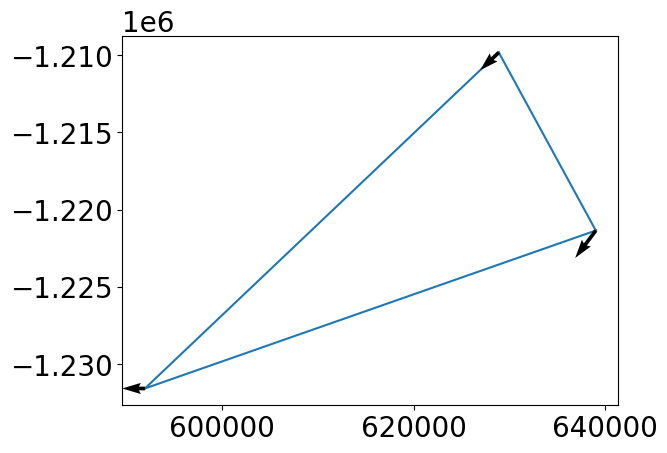

In [8]:
xm, ym = [np.array([drifters[str(gd)][i] for gd in good_drifters]) for i in ['xi', 'yi']]
um = np.diff(xm)/(24*60*60*delta_t)
vm = np.diff(ym)/(24*60*60*delta_t)

plt.triplot(xm[:, 0], ym[:, 0])
plt.quiver(xm[:, 0], ym[:, 0], um[:, 0], vm[:, 0])

plt.savefig("triangle_illustration.pdf")
plt.savefig("triangle_illustration.png")

In [9]:
from matplotlib.tri import Triangulation

def get_deformation_elems(x, y, u, v, a):
    """ Compute deformation for given elements.
    Input X, Y, U, V are organized in three columns: for each node of M elements.
    To convert deformation rates from 1/s to %/day outputs should be multiplied by 8640000.
    Parameters
    ----------
    x : 3xM ndarray
        X-coordinates of nodes, m
    y : 3xM ndarray
        Y-coordinates of nodes, m
    u : 3xM ndarray
        U-component of nodes, m/s
    v : 3xM ndarray
        V-component of nodes, m/s
    a : Mx1 ndarray
        area of elements, m2
    Returns
    -------
    e1 : Mx1 array
        Divergence, 1/s
    e2 : Mx1 array
        Shear, 1/s
    e3 : Mx1 array
        Vorticity, 1/s
    """
    # contour integrals of u and v [m/s * m ==> m2/s]
    ux = uy = vx = vy = 0
    for i0, i1 in zip([1, 2, 0], [0, 1, 2]):
        ux += (u[i0] + u[i1]) * (y[i0] - y[i1])
        uy -= (u[i0] + u[i1]) * (x[i0] - x[i1])
        vx += (v[i0] + v[i1]) * (y[i0] - y[i1])
        vy -= (v[i0] + v[i1]) * (x[i0] - x[i1])
    # divide integral by double area [m2/s / m2 ==> 1/day]
    ux, uy, vx, vy =  [i / (2 * a) for i in (ux, uy, vx, vy)]

    # deformation components
    e1 = ux + vy
    e2 = ((ux - vy) ** 2 + (uy + vx) ** 2) ** 0.5
    e3 = vx - uy

    return e1, e2, e3

def get_deformation_on_triangulation(x, y, u, v, t):
    """ Compute deformation for given nodes.
    Input X, Y, U, V are given for individual N nodes. Nodes coordinates are triangulated and
    area, perimeter and deformation is computed for M elements.
    Parameters
    ----------
    x : Nx1 ndarray
        X-coordinates of nodes, m
    y : Nx1 ndarray
        Y-coordinates of nodes, m
    u : Nx1 ndarray
        U-component of nodes, m/s
    v : Nx1 ndarray
        V-component of nodes, m/s
    t : 3xM array
        Triangulation (indices of input nodes for each element)
    Returns
    -------
    e1 : Mx1 array
        Divergence, 1/s
    e2 : Mx1 array
        Shear, 1/s
    e3 : Mx1 array
        Vorticity, 1/s
    a : Mx1 array
        Area, m2
    p : Mx1 array
        Perimeter, m
    """

    # coordinates and speeds of corners of each element
    xt, yt, ut, vt = [i[t].T for i in (x, y, u, v)]

    # side lengths (X,Y,tot)
    tri_x = np.diff(np.vstack([xt, xt[0]]), axis=0)
    tri_y = np.diff(np.vstack([yt, yt[0]]), axis=0)
    tri_s = np.hypot(tri_x, tri_y)
    # perimeter
    tri_p = np.sum(tri_s, axis=0)
    s = tri_p/2
    # area
    tri_a = np.sqrt(s * (s - tri_s[0]) * (s - tri_s[1]) * (s - tri_s[2]))

    # deformation components
    e1, e2, e3 = get_deformation_elems(xt, yt, ut, vt, tri_a)

    return e1, e2, e3, tri_a, tri_p


In [10]:
tri = Triangulation(xm[:, 0], ym[:, 0])
e1s, e2s, e3s, xes, yes = [], [], [], [], []
for i in range(um.shape[1]):
    e1, e2, e3, tri_a, tri_p = get_deformation_on_triangulation(xm[:, i], ym[:, i], um[:, i], vm[:, i], tri.triangles)
    e1s.append(e1)
    e2s.append(e2)
    e2s.append(e3)
    xes.append(xm[:, i][tri.triangles].mean(axis=1))
    yes.append(ym[:, i][tri.triangles].mean(axis=1))

e1s, e2s, e3s = [np.array(i)*24*60*60*100 for i in [e1s, e2s, e3s]]
xes = np.array(xes)
yes = np.array(yes)

In [11]:
plt_dates = [t0 + datetime.timedelta(days=i) for i in ui[:-1]]

/tmp/ipykernel_3747653/1290345318.py:37: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=65)


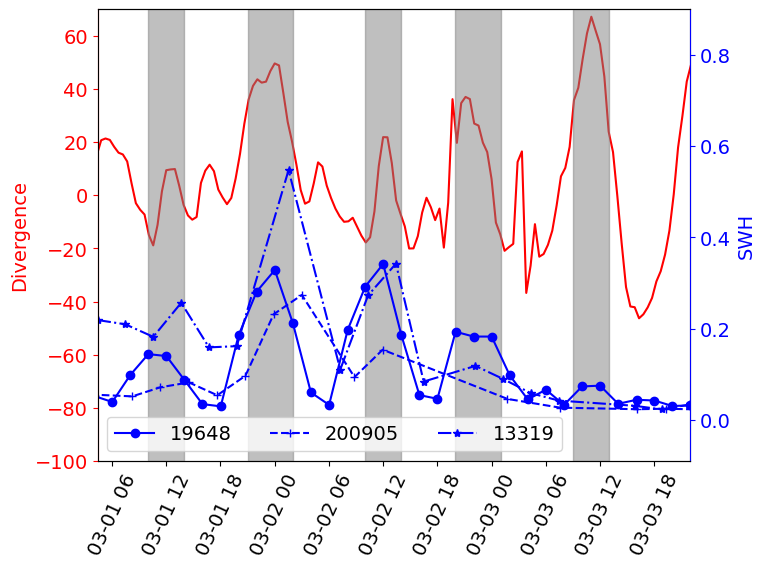

In [12]:
plt.rcParams.update({'font.size': 14})

cm = 1/2.54  # centimeters in inches
fig = plt.figure(dpi=100, figsize=(20*cm, 15*cm))
ax = fig.add_subplot(111)

ax.plot(plt_dates, e1s, color="r")
ax.set_ylim([-100, 70])

list_markers = ["o", "+", "*"]
list_styles = ["-", "--", "-."]

ax2 = ax.twinx()
for crrt_index, crrt_instrument in enumerate(list_most_relevant_instruments):
    ax2.plot(
        # dict_lists_data_relevant[crrt_instrument]["twh"], dict_lists_data_relevant[crrt_instrument]["swh"],
        dict_lists_data_all[crrt_instrument]["twh"], np.array(dict_lists_data_all[crrt_instrument]["swh"]),
        marker=list_markers[crrt_index], linestyle=list_styles[crrt_index], alpha=1.0,
        color="blue",
        label=instrument_label(crrt_instrument).split(" ")[0]
    )
    
ax2.set_ylim([-0.09, 0.9])

ax.set_ylabel("Divergence")
ax2.set_ylabel("SWH")

ax.spines['left'].set_color('red')
ax.yaxis.label.set_color('red')
ax.tick_params(axis='y', colors='red')

ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')

ax.set_xlim([dict_lists_data_all[crrt_instrument]["twh"][0], dict_lists_data_all[crrt_instrument]["twh"][-1]])
ax.set_xticklabels(ax.get_xticklabels(), rotation=65)

ax2.axvspan(datetime.datetime(2021,3,1,10), datetime.datetime(2021,3,1,14), alpha=0.5, color='grey')
ax2.axvspan(datetime.datetime(2021,3,1,21), datetime.datetime(2021,3,2,2), alpha=0.5, color='grey')
ax2.axvspan(datetime.datetime(2021,3,2,10), datetime.datetime(2021,3,2,14), alpha=0.5, color='grey')
ax2.axvspan(datetime.datetime(2021,3,2,20), datetime.datetime(2021,3,3,1), alpha=0.5, color='grey')
ax2.axvspan(datetime.datetime(2021,3,3,9), datetime.datetime(2021,3,3,13), alpha=0.5, color='grey')

plt.tight_layout()

ax2.legend(loc="lower left", ncol=3)

plt.savefig("convergence_divergence_swh_3_bois.pdf")
plt.savefig("convergence_divergence_swh_3_bois.png")

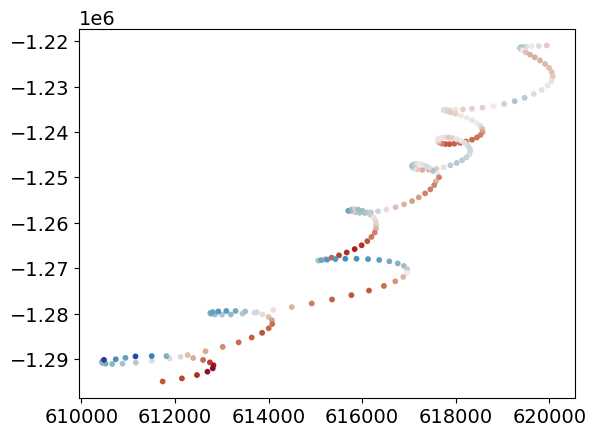

In [22]:
from cmocean import cm as cmp

for i in range(xes.shape[1]):
    plt.scatter(xes[:, i], yes[:, i], 10, e1s[:, i], vmin=-100, vmax=100, cmap=cmp.balance)

plt.savefig("center_with_color_convergence_divergence.pdf")
plt.savefig("center_with_color_convergence_divergence.png")

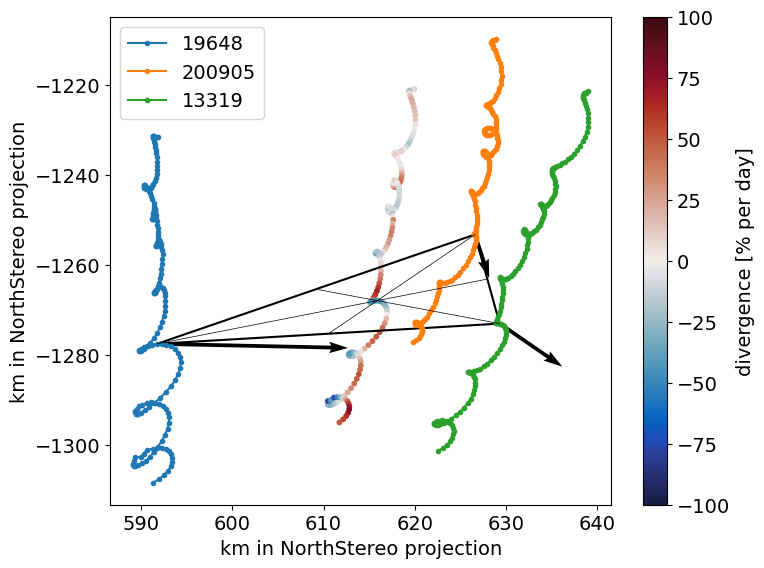

In [23]:
plt.rcParams.update({'font.size': 14})

cm = 1/2.54  # centimeters in inches
fig = plt.figure(dpi=100, figsize=(20*cm, 15*cm))
ax = fig.add_subplot(111)

list_d = [] 

for gd in good_drifters:
    d = drifters[str(gd)]
    list_d.append(str(gd))
    # plt.plot(d['x'], d['y'], 'o')
    plt.plot(d['xi']/1e3, d['yi']/1e3, '.-', label=str(gd))

for i in range(xes.shape[1]):
    plt.scatter(xes[:, i]/1e3, yes[:, i]/1e3, 10, e1s[:, i], vmin=-100, vmax=100, cmap=cmp.balance)
    
cbar = plt.colorbar()
cbar.set_label('divergence [% per day]')
    
idx_example_triangle = 135
plt.triplot(xm[:, idx_example_triangle]/1e3, ym[:, idx_example_triangle]/1e3, color="k")
plt.quiver(xm[:, idx_example_triangle]/1e3, ym[:, idx_example_triangle]/1e3, um[:, idx_example_triangle], vm[:, idx_example_triangle], scale=0.8, color="k")

d1 = drifters[list_d[0]]
d2 = drifters[list_d[1]]
d3 = drifters[list_d[2]]

plt.plot([d1['xi'][idx_example_triangle]/1e3, (d2['xi'][idx_example_triangle] + d3['xi'][idx_example_triangle])/2.0/1e3], [d1['yi'][idx_example_triangle]/1e3, (d2['yi'][idx_example_triangle] + d3['yi'][idx_example_triangle])/2.0/1e3], color="k", linewidth=0.5)
plt.plot([d2['xi'][idx_example_triangle]/1e3, (d1['xi'][idx_example_triangle] + d3['xi'][idx_example_triangle])/2.0/1e3], [d2['yi'][idx_example_triangle]/1e3, (d1['yi'][idx_example_triangle] + d3['yi'][idx_example_triangle])/2.0/1e3], color="k", linewidth=0.5)
plt.plot([d3['xi'][idx_example_triangle]/1e3, (d2['xi'][idx_example_triangle] + d1['xi'][idx_example_triangle])/2.0/1e3], [d3['yi'][idx_example_triangle]/1e3, (d2['yi'][idx_example_triangle] + d1['yi'][idx_example_triangle])/2.0/1e3], color="k", linewidth=0.5)

plt.legend()

plt.xlabel("km in NorthStereo projection")
plt.ylabel("km in NorthStereo projection")

plt.tight_layout()

plt.savefig("triangulation_divergence_analysis.png")
plt.savefig("triangulation_divergence_analysis.pdf")

In [24]:
# compare to the model for the sea ice convergence and divergence

In [25]:
# files with the model ice divergence information
xa_ice_his_0 = xa.open_dataset( '../../common_nc_data/ice_his.an.20210301.nc')                    
xa_ice_his_1 = xa.open_dataset('../../common_nc_data/ice_his.an.20210302.nc')                    
xa_ice_his_2 = xa.open_dataset('../../common_nc_data/ice_his.an.20210303.nc') 

# Concatenate subset of sea ice convergence data
ds_concat = xa.concat(
    (
        xa_ice_his_0.divu_h.isel(nj=np.arange(350,650),ni=np.arange(100,500)),
        xa_ice_his_1.divu_h.isel(nj=np.arange(350,650),ni=np.arange(100,500)),
        xa_ice_his_2.divu_h.isel(nj=np.arange(350,650),ni=np.arange(100,500))
    ),
    dim='time')#,data_vars=['divu_h','forecast_reference_time'])

In [26]:
ds_concat

<xarray.DataArray 'divu_h' (time: 72, nj: 300, ni: 400)> Size: 35MB
array([[[ -62.088116 ,  -75.64215  , -101.49446  , ...,    0.       ,
            0.       ,    0.       ],
        [ -50.247383 ,  -73.73148  , -111.65885  , ...,    0.       ,
            0.       ,    0.       ],
        [ -33.85958  ,  -45.696953 ,  -75.62282  , ...,    0.       ,
            0.       ,    0.       ],
        ...,
        [   3.260686 ,    3.1583087,    2.9489276, ...,    0.       ,
            0.       ,    0.       ],
        [   3.2358906,    3.3665588,    3.3844807, ...,    0.       ,
            0.       ,    0.       ],
        [   2.933282 ,    3.273795 ,    3.4607031, ...,    0.       ,
            0.       ,    0.       ]],

       [[ -65.4821   ,  -64.55626  ,  -79.53288  , ...,    0.       ,
            0.       ,    0.       ],
        [ -50.344025 ,  -60.29653  ,  -82.719124 , ...,    0.       ,
            0.       ,    0.       ],
        [ -43.11196  ,  -46.319263 ,  -57.344093 , ...,    0.       ,
            0.       ,    0.       ],
...
        [   8.836645 ,    8.276139 ,    4.732638 , ...,    0.       ,
            0.       ,    0.       ],
        [  10.5999775,   10.176837 ,    5.819824 , ...,    0.       ,
            0.       ,    0.       ],
        [   9.204792 ,    8.938511 ,    5.12543  , ...,    0.       ,
            0.       ,    0.       ]],

       [[ -45.59657  ,  -68.28089  ,  -50.58992  , ...,    0.       ,
            0.       ,    0.       ],
        [ -66.19234  , -102.050835 ,  -85.76691  , ...,    0.       ,
            0.       ,    0.       ],
        [ -51.458855 ,  -37.28844  ,  -63.48411  , ...,    0.       ,
            0.       ,    0.       ],
        ...,
        [   7.634938 ,    6.488877 ,    2.4960408, ...,    0.       ,
            0.       ,    0.       ],
        [  10.164103 ,    8.317129 ,    2.9713054, ...,    0.       ,
            0.       ,    0.       ],
        [   9.39525  ,    7.032748 ,    1.1978136, ...,    0.       ,
            0.       ,    0.       ]]], dtype=float32)
Coordinates:
    TLAT     (nj, ni) float32 480kB 76.45 76.44 76.43 ... 75.19 75.17 75.15
    TLON     (nj, ni) float32 480kB 355.7 355.8 355.9 356.0 ... 42.26 42.3 42.33
    ULAT     (nj, ni) float32 480kB 76.45 76.45 76.44 ... 75.18 75.16 75.14
    ULON     (nj, ni) float32 480kB -4.23 -4.14 -4.05 ... 42.32 42.36 42.39
  * time     (time) datetime64[ns] 576B 2021-03-01 ... 2021-03-03T23:00:00
Dimensions without coordinates: nj, ni
Attributes:
    units:          %/day
    long_name:      strain rate (divergence)
    cell_measures:  area: tarea
    time_rep:       instantaneous

In [27]:
def find_indices(lon_field, lat_field, lon_pt, lat_pt):
    """Get closest indices to lat_pt (latitude point)/lon_pt in a lat/lon field"""
    abslat = np.abs(lat_field-lat_pt)
    abslon= np.abs(lon_field-lon_pt)

    c = np.maximum(abslon, abslat)
    #print(np.where(c==np.min(c)))
    x, y = np.where(c == np.min(c))
    return x[0],y[0]

In [28]:
# NOTE: this is SLOW!!! (easily a few minutes)

# build the dataset of the strain rate at the time and location of the barycenters, for comparison model vs. obs

# we want to get the value at the barycenter of 19648, 200905, 13319
# we need to use the interpolated location and time, so that the 3 drifters become collocated in time

list_center_lats = []
list_center_lons = []

list_idx = []
list_idy = []

list_divuh = []
list_smooth_divuh = []

lon_field = ds_concat["ULON"]
lat_field = ds_concat["ULAT"]

# times of interpolation
for crrt_step, crrt_time in enumerate(plt_dates):
    # lat and lon of the interpolated center
    crrt_lat = (d1["latsi"][crrt_step] + d2["latsi"][crrt_step] + d3["latsi"][crrt_step]) / 3.0
    crrt_lon = (d1["lonsi"][crrt_step] + d2["lonsi"][crrt_step] + d3["lonsi"][crrt_step]) / 3.0

    list_center_lats.append(crrt_lat)
    list_center_lons.append(crrt_lon)

    # closest point in lat and lon
    idx, idy = find_indices(lon_field, lat_field, crrt_lon, crrt_lat)

    list_idx.append(idx)
    list_idy.append(idy)

    # interpolate in time and space from the model
    crrt_divuh = ds_concat.interp(time=crrt_time)[idx, idy]

    # use a slightly smoothed version to avoid numerical artifacts
    crrt_acc_divuh = 0
    crrt_n_acc = 0
    for crrt_acc_time in [crrt_time, crrt_time-datetime.timedelta(minutes=30), crrt_time+datetime.timedelta(minutes=30)]:
        for crrt_acc_idx in [idx+1, idx-1, idx]:
            for crrt_acc_idy in [idy+1, idy-1, idy]:
                crrt_n_acc += 1
                crrt_acc_divuh += ds_concat.interp(time=crrt_acc_time)[crrt_acc_idx, crrt_acc_idy]
    crrt_smooth_divuh = crrt_acc_divuh / crrt_n_acc

    list_divuh.append(crrt_divuh)
    list_smooth_divuh.append(crrt_smooth_divuh)

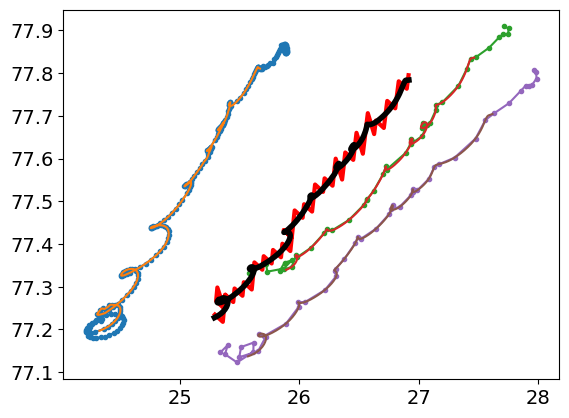

In [29]:
# a few plots and prints to perform double checking

plt.figure()
for gd in good_drifters:
    d = drifters[str(gd)]
    plt.plot(d['lons'], d['lats'], '.-')
    plt.plot(d['lonsi'], d['latsi'])

list_ulons = [ds_concat["ULON"][crrt_idx, crrt_idy] for (crrt_idx, crrt_idy) in zip(list_idx, list_idy)]
list_ulats = [ds_concat["ULAT"][crrt_idx, crrt_idy] for (crrt_idx, crrt_idy) in zip(list_idx, list_idy)]
plt.plot(list_ulons, list_ulats, color="r", linewidth=3)

plt.plot(list_center_lons, list_center_lats, color="k", linewidth=4)

/tmp/ipykernel_3747653/933402080.py:41: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=65)


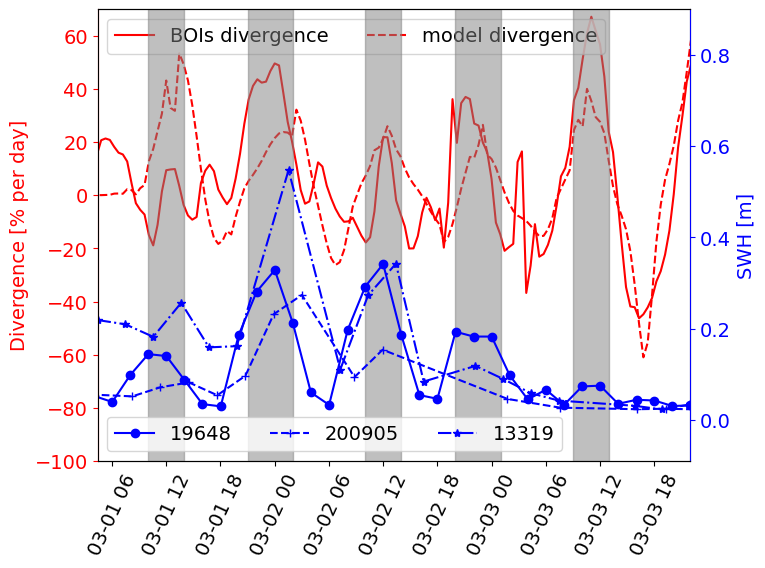

In [30]:
# previous figure, extended with the convergence / divergence from the model

plt.rcParams.update({'font.size': 14})

cm = 1/2.54  # centimeters in inches
fig = plt.figure(dpi=100, figsize=(20*cm, 15*cm))
ax = fig.add_subplot(111)

ax.plot(plt_dates, e1s, color="r", label="BOIs divergence")
ax.plot(plt_dates, list_smooth_divuh, color="r", label="model divergence", linestyle="--")
# ax.plot(plt_dates, list_divuh, color="r", label="model divergence", linestyle="--")
ax.set_ylim([-100, 70])

list_markers = ["o", "+", "*"]
list_styles = ["-", "--", "-."]

ax2 = ax.twinx()
for crrt_index, crrt_instrument in enumerate(list_most_relevant_instruments):
    ax2.plot(
        # dict_lists_data_relevant[crrt_instrument]["twh"], dict_lists_data_relevant[crrt_instrument]["swh"],
        dict_lists_data_all[crrt_instrument]["twh"], np.array(dict_lists_data_all[crrt_instrument]["swh"]),
        marker=list_markers[crrt_index], linestyle=list_styles[crrt_index], alpha=1.0,
        color="blue",
        label=instrument_label(crrt_instrument).split(" ")[0]
    )
    
ax2.set_ylim([-0.09, 0.9])

ax.set_ylabel("Divergence [% per day]")
ax2.set_ylabel("SWH [m]")

ax.spines['left'].set_color('red')
ax.yaxis.label.set_color('red')
ax.tick_params(axis='y', colors='red')

ax2.spines['right'].set_color('blue')
ax2.yaxis.label.set_color('blue')
ax2.tick_params(axis='y', colors='blue')

ax.set_xlim([dict_lists_data_all[crrt_instrument]["twh"][0], dict_lists_data_all[crrt_instrument]["twh"][-1]])
ax.set_xticklabels(ax.get_xticklabels(), rotation=65)

ax2.axvspan(datetime.datetime(2021,3,1,10), datetime.datetime(2021,3,1,14), alpha=0.5, color='grey')
ax2.axvspan(datetime.datetime(2021,3,1,21), datetime.datetime(2021,3,2,2), alpha=0.5, color='grey')
ax2.axvspan(datetime.datetime(2021,3,2,10), datetime.datetime(2021,3,2,14), alpha=0.5, color='grey')
ax2.axvspan(datetime.datetime(2021,3,2,20), datetime.datetime(2021,3,3,1), alpha=0.5, color='grey')
ax2.axvspan(datetime.datetime(2021,3,3,9), datetime.datetime(2021,3,3,13), alpha=0.5, color='grey')

plt.tight_layout()

ax2.legend(loc="lower left", ncol=3)
ax.legend(loc="upper left", ncol=2)

plt.savefig("convergence_divergence_swh_3_bois_withmodel.pdf")
plt.savefig("convergence_divergence_swh_3_bois_withmodel.png")

np.float64(0.7139446926234471)

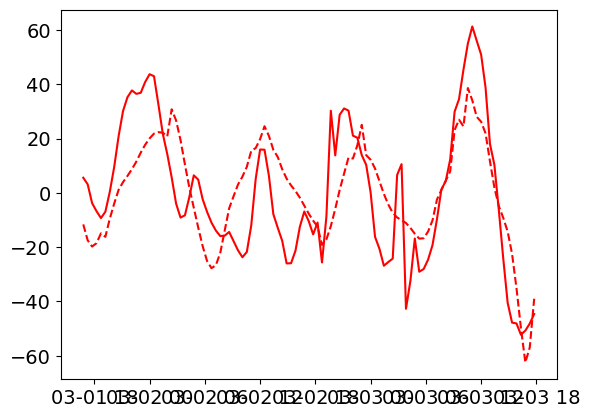

In [49]:
# the time when the 3 modulation peaks happen, over which we want to compare the model and the buoys
start = 35
end = 138

e1s = np.squeeze(e1s)
list_smooth_divuh = np.squeeze(list_smooth_divuh)

x = e1s[start:end]
y = list_smooth_divuh[start:end]

x = x - np.mean(x)
y = y - np.mean(y)

plt.figure()
plt.plot(plt_dates[start:end], x, color="r", label="BOIs divergence")
plt.plot(plt_dates[start:end], y, color="r", label="model divergence", linestyle="--")
plt.show

import scipy as sp


def pearson(X, Y): #arrays
     slope, intercept, pearson, p_value, std_err = sp.stats.linregress(X,Y)
     return pearson


rsquared(x, y)